In [25]:
import os
import sys
import re
# =========================================================
# 1. ÉP VERSION PYSPARK (PHẢI CHẠY ĐẦU TIÊN TRƯỚC KHI IMPORT)
# =========================================================
modules_to_remove = [mod for mod in sys.modules if mod.startswith('pyspark') or mod.startswith('py4j')]
for mod in modules_to_remove: 
    del sys.modules[mod]

sys.path = [p for p in sys.path if "/usr/local/spark" not in p]
if "PYTHONPATH" in os.environ: 
    del os.environ["PYTHONPATH"]
    
conda_site_packages = "/opt/conda/lib/python3.13/site-packages"
if conda_site_packages not in sys.path: 
    sys.path.insert(0, conda_site_packages)
    
os.environ["SPARK_HOME"] = os.path.join(conda_site_packages, "pyspark")
os.environ["PYSPARK_PYTHON"] = "python3"
os.environ["PYSPARK_DRIVER_PYTHON"] = "python3"


# =========================================================
# 2. BÂY GIỜ MỚI IMPORT PYSPARK VÀ KHỞI TẠO SESSION
# =========================================================
import numpy as np
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, udf, concat_ws
from pyspark.sql.types import IntegerType, StringType
from pyspark.ml.feature import StopWordsRemover, CountVectorizer
from pyspark.ml.clustering import LDA
spark = SparkSession.builder \
    .appName("LSTM_word2vec_token_Pipeline") \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.memory", "8g") \
    .config("spark.memory.offHeap.enabled", "true") \
    .config("spark.memory.offHeap.size", "2g") \
    .config("spark.driver.maxResultSize", "2g") \
    .config("spark.jars.packages", "org.apache.hadoop:hadoop-aws:3.3.4,com.amazonaws:aws-java-sdk-bundle:1.12.262,org.apache.iceberg:iceberg-spark-runtime-3.5_2.12:1.5.0") \
    .config("spark.hadoop.fs.s3a.endpoint", "http://minio:9000") \
    .config("spark.hadoop.fs.s3a.access.key", "dataNLPmining-lab") \
    .config("spark.hadoop.fs.s3a.secret.key", "dataNLPmining-lab") \
    .config("spark.hadoop.fs.s3a.path.style.access", "true") \
    .config("spark.hadoop.fs.s3a.connection.ssl.enabled", "false") \
    .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem") \
    .config("spark.hadoop.fs.s3a.aws.credentials.provider", "org.apache.hadoop.fs.s3a.SimpleAWSCredentialsProvider") \
    .config("spark.sql.extensions", "org.apache.iceberg.spark.extensions.IcebergSparkSessionExtensions") \
    .config("spark.sql.catalog.my_catalog", "org.apache.iceberg.spark.SparkCatalog") \
    .config("spark.sql.catalog.my_catalog.type", "hadoop") \
    .config("spark.sql.catalog.my_catalog.warehouse", "s3a://raw-financial-data/iceberg_warehouse") \
    .getOrCreate()


# =========================================================
# 3. VÁ LỖI THỜI GIAN HADOOP
# =========================================================
hadoop_conf = spark._jsc.hadoopConfiguration()
iterator = hadoop_conf.iterator()
while iterator.hasNext():
    entry = iterator.next()
    val = str(entry.getValue()).strip().lower()
    match = re.fullmatch(r"(\d+)([smhd])", val)
    if match:
        num, unit = int(match.group(1)), match.group(2)
        ms_val = num * 1000 if unit == 's' else num * 60000 if unit == 'm' else num * 3600000 if unit == 'h' else num * 86400000
        hadoop_conf.set(entry.getKey(), str(ms_val))

print("✅ Khởi tạo Spark và môi trường hoàn tất!")

✅ Khởi tạo Spark và môi trường hoàn tất!


In [26]:
# Đọc bảng như một Spark DataFrame
df_market_data = spark.table("my_catalog.raw_zone_finnhub.market_data_clean")

# Hiển thị 5 dòng đầu tiên
df_market_data.show(50)

# Kiểm tra schema của dữ liệu
df_market_data.printSchema()

+----------+------------------+------------------+------------------+------------------+---------+---------+------------+
|trade_date|        open_price|        high_price|         low_price|       close_price|   volume|dividends|stock_splits|
+----------+------------------+------------------+------------------+------------------+---------+---------+------------+
|2025-06-17| 144.2978018718573| 145.0268265438421|143.58873962374116|143.92828369140625|139108000|      0.0|         0.0|
|2025-06-18|143.81843788371728| 145.4562558084884|142.92962233744194|145.28648376464844|161494100|      0.0|         0.0|
|2025-06-20| 145.2565234707711|146.00552584195606|142.46024490398213|143.65866088867188|242956200|      0.0|         0.0|
|2025-06-23|142.31046402404658|144.58743022935184|141.84108794116847|143.97824096679688|154308900|      0.0|         0.0|
|2025-06-24|145.36637857516104|147.76319531946535| 145.3064608232896|147.70326232910156|187566100|      0.0|         0.0|
|2025-06-25| 149.0714619

In [28]:
from pyspark.sql import functions as F

# Đọc bảng dữ liệu (Giữ nguyên của bạn)
df_tokenize = spark.read.table("my_catalog.processed_zone_finnhub.news_VADER_tokens_sentiment_score")

df_tokenize_unique = df_tokenize.dropDuplicates(["id"])

# Tạo cột ngày
df_tokenize_with_date = df_tokenize_unique.withColumn("date_only", F.to_date("published_at"))

df_joined = df_tokenize_with_date.join(
    F.broadcast(df_market_data),
    df_tokenize_with_date.date_only == df_market_data.trade_date,
    "inner" 
)

# Dọn dẹp cột thừa
df_final = df_joined.drop("date_only")

print("✅ Đã Join và xử lý dữ liệu thành công!")


df_final.show(5)

✅ Đã Join và xử lý dữ liệu thành công!
+---------+-------------------+--------------------+--------------------+--------------------+--------------------+-----------------+-------------------+---------------------+-----------------------+----------+------------------+------------------+-----------------+-----------------+-------+---------+------------+
|       id|       published_at|        title_tokens|      summary_tokens|          title_text|        summary_text|title_vader_score|summary_vader_score|title_vader_sentiment|summary_vader_sentiment|trade_date|        open_price|        high_price|        low_price|      close_price| volume|dividends|stock_splits|
+---------+-------------------+--------------------+--------------------+--------------------+--------------------+-----------------+-------------------+---------------------+-----------------------+----------+------------------+------------------+-----------------+-----------------+-------+---------+------------+
|118199294|20

In [30]:

ngay_kiem_tra = "2026-06-17"

# 1. Lấy ra chính xác con số (trả về một số nguyên)
count_for_day = df_final.filter(df_final.trade_date == ngay_kiem_tra).count()
print(f"Số lượng bài báo trong ngày {ngay_kiem_tra} là: {count_for_day}")

# 2. (Tùy chọn) Xem chi tiết tiêu đề của các bài báo trong ngày đó
print(f"\n--- Chi tiết các bài báo ngày {ngay_kiem_tra} ---")
df_final.filter(df_final.trade_date == ngay_kiem_tra) \
    .select("published_at", "title_tokens", "summary_vader_score") \
    .show(truncate=False)

Số lượng bài báo trong ngày 2026-06-17 là: 536

--- Chi tiết các bài báo ngày 2026-06-17 ---
+-------------------+------------------------------------------------------------------------------------------------------------------+-------------------+
|published_at       |title_tokens                                                                                                      |summary_vader_score|
+-------------------+------------------------------------------------------------------------------------------------------------------+-------------------+
|2026-06-17 00:21:16|[applied, materials, stock, shouting, surge]                                                                      |0.1779             |
|2026-06-17 03:13:53|[crm, foxa, glnd, stocks, fall, week, lows, tuesday]                                                              |0.3612             |
|2026-06-17 03:21:50|[dell, dell, faces, million, xtx, lawsuit, server, pricing]                                          

--- Dữ liệu sau khi làm sạch và gom nhóm theo ngày ---
+----------+-----------------+-------------------+----------+
|trade_date|      close_price|    avg_vader_score|news_count|
+----------+-----------------+-------------------+----------+
|2025-10-27|  95.118896484375|0.30423038338755704|      1221|
|2025-10-28|94.55995178222656| 0.3059047481620172|      1937|
|2025-10-29|93.86128234863281| 0.2835312545360249|      2086|
|2025-10-30|93.22249603271484|0.30691128051406075|      2083|
|2025-10-31| 94.8194580078125| 0.2978733809152744|      1484|
+----------+-----------------+-------------------+----------+
only showing top 5 rows

--- Dữ liệu Tín hiệu Giao dịch Hoàn chỉnh (SMA 20 + Z-Score) ---
+----------+------------------+-----------------+-------------------+-------------------+------+
|trade_date|       close_price|           sma_20|    avg_vader_score|  sentiment_z_score|signal|
+----------+------------------+-----------------+-------------------+-------------------+------+
|2025-

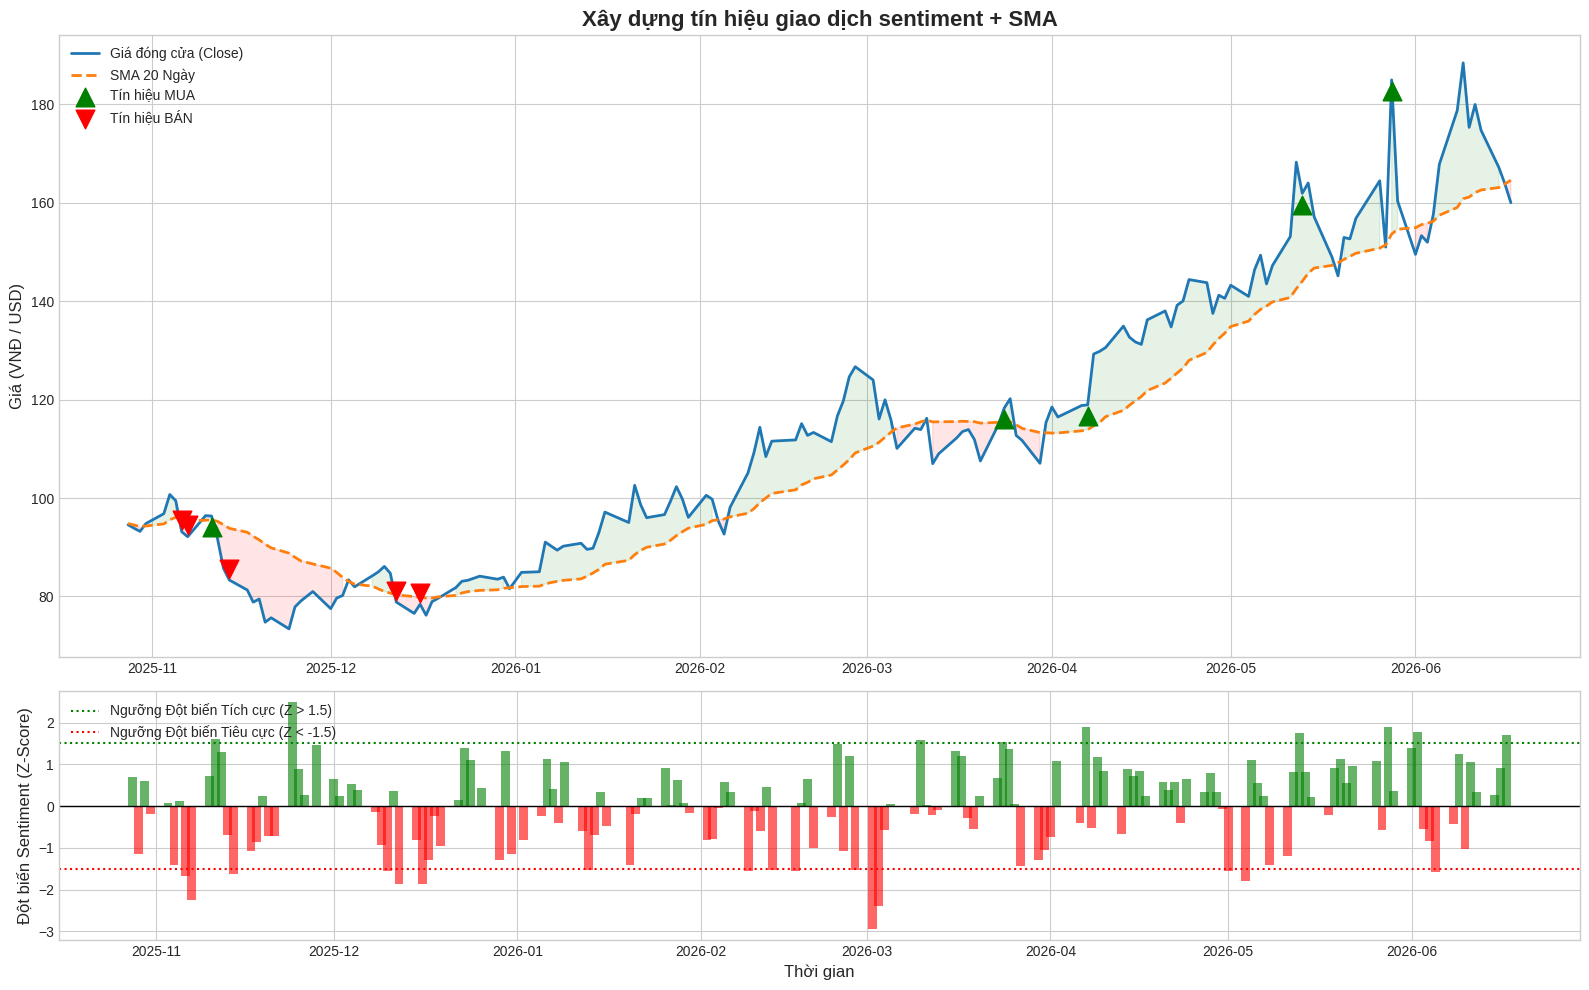

In [34]:
# =========================================================
# BƯỚC 1: LỌC DỮ LIỆU LỖI & GOM NHÓM Theo NGÀY
# =========================================================
from pyspark.sql import functions as F
from pyspark.sql.window import Window

# 1. Lọc bỏ phần dữ liệu giá bị trộn lẫn (giá > 1000)
df_clean = df_final.filter(F.col("close_price") < 1000)

# 2. Gom nhóm tính trung bình điểm Sentiment mỗi ngày
df_daily = df_clean.groupBy("trade_date", "close_price").agg(
    F.mean("summary_vader_score").alias("avg_vader_score"),
    F.count("id").alias("news_count")
).orderBy("trade_date")

print("--- Dữ liệu sau khi làm sạch và gom nhóm theo ngày ---")
df_daily.show(5)


# =========================================================
# BƯỚC 2: TÍNH SMA 20 NGÀY & Z-SCORE (1 THÁNG GIAO DỊCH)
# =========================================================

# Khai báo Window phân vùng theo thời gian (20 ngày giao dịch gần nhất)
# CẬP NHẬT: Lùi về trước 19 dòng + 1 dòng hiện tại = 20 dòng (20 ngày)
window_20 = Window.orderBy("trade_date").rowsBetween(-19, Window.currentRow)

# Tính SMA 20 và các chỉ số thống kê (Mean, Std) của Sentiment trong 20 ngày
df_processed = df_daily.withColumn(
    "sma_20", F.avg("close_price").over(window_20)
).withColumn(
    "sentiment_mean_20", F.avg("avg_vader_score").over(window_20)
).withColumn(
    "sentiment_std_20", F.stddev("avg_vader_score").over(window_20)
)

# Tính Z-Score cho Sentiment
# Đảm bảo không chia cho 0 bằng F.when
df_processed = df_processed.withColumn(
    "sentiment_z_score", 
    (F.col("avg_vader_score") - F.col("sentiment_mean_20")) / F.when(F.col("sentiment_std_20") == 0, 1).otherwise(F.col("sentiment_std_20"))
)


# =========================================================
# BƯỚC 3: XÂY DỰNG TÍN HIỆU GIAO DỊCH 
# =========================================================

# Sử dụng ngưỡng Z-score = 1.5 
z_threshold = 1.5

df_signals = df_processed.withColumn(
    "signal",
    F.when(
        (F.col("close_price") > F.col("sma_20")) & (F.col("sentiment_z_score") > z_threshold), 1 # MUA
    ).when(
        (F.col("close_price") < F.col("sma_20")) & (F.col("sentiment_z_score") < -z_threshold), -1 # BÁN
    ).otherwise(0) # ĐỨNG NGOÀI
)

# Xóa các dòng bị Null ở 19 ngày đầu tiên do chưa đủ dữ liệu tính Window
df_signals = df_signals.dropna(subset=["sma_20", "sentiment_z_score"])

print("--- Dữ liệu Tín hiệu Giao dịch Hoàn chỉnh (SMA 20 + Z-Score) ---")
df_signals.select("trade_date", "close_price", "sma_20", "avg_vader_score", "sentiment_z_score", "signal").show(10)


# =========================================================
# BƯỚC 4: LẤY VỀ PANDAS VÀ VẼ BIỂU ĐỒ MATPLOTLIB
# =========================================================
import matplotlib.pyplot as plt

# Chuyển dữ liệu Spark thành Pandas DataFrame để vẽ
pdf_plot = df_signals.toPandas()

# Thiết lập phong cách biểu đồ
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={'height_ratios': [3, 1.2]})

# --- BIỂU ĐỒ TRÊN: GIÁ VÀ SMA 20 ---
ax1.plot(pdf_plot['trade_date'], pdf_plot['close_price'], label='Giá đóng cửa (Close)', color='#1f77b4', linewidth=2)
# CẬP NHẬT: Vẽ đường sma_20
ax1.plot(pdf_plot['trade_date'], pdf_plot['sma_20'], label='SMA 20 Ngày', color='#ff7f0e', linestyle='--', linewidth=2)

ax1.set_title('Xây dựng tín hiệu giao dịch sentiment + SMA', fontsize=16, fontweight='bold')
ax1.set_ylabel('Giá (VNĐ / USD)', fontsize=12)
ax1.legend(loc='upper left')

# Đánh dấu vùng Giá cắt SMA 20
ax1.fill_between(pdf_plot['trade_date'], pdf_plot['close_price'], pdf_plot['sma_20'], 
                 where=(pdf_plot['close_price'] > pdf_plot['sma_20']), color='green', alpha=0.1)
ax1.fill_between(pdf_plot['trade_date'], pdf_plot['close_price'], pdf_plot['sma_20'], 
                 where=(pdf_plot['close_price'] < pdf_plot['sma_20']), color='red', alpha=0.1)

# Vẽ điểm MUA và BÁN
buy_signals = pdf_plot[pdf_plot['signal'] == 1]
sell_signals = pdf_plot[pdf_plot['signal'] == -1]

price_offset = pdf_plot['close_price'].mean() * 0.02 

ax1.scatter(buy_signals['trade_date'], buy_signals['close_price'] - price_offset, 
            marker='^', color='green', s=180, label='Tín hiệu MUA', zorder=5)
ax1.scatter(sell_signals['trade_date'], sell_signals['close_price'] + price_offset, 
            marker='v', color='red', s=180, label='Tín hiệu BÁN', zorder=5)
ax1.legend(loc='upper left')

# --- BIỂU ĐỒ DƯỚI: SENTIMENT Z-SCORE ---
colors = ['green' if x > 0 else 'red' for x in pdf_plot['sentiment_z_score']]
ax2.bar(pdf_plot['trade_date'], pdf_plot['sentiment_z_score'], color=colors, alpha=0.6, width=1.5)

ax2.axhline(0, color='black', linewidth=1)
ax2.axhline(z_threshold, color='green', linestyle=':', linewidth=1.5, label=f'Ngưỡng Đột biến Tích cực (Z > {z_threshold})')
ax2.axhline(-z_threshold, color='red', linestyle=':', linewidth=1.5, label=f'Ngưỡng Đột biến Tiêu cực (Z < {-z_threshold})')

ax2.set_ylabel('Đột biến Sentiment (Z-Score)', fontsize=12)
ax2.set_xlabel('Thời gian', fontsize=12)
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [35]:
!pip install backtrader

🔍 Đang tìm kiếm dữ liệu thật của bạn trong bộ nhớ RAM...
✅ Đã tìm thấy dữ liệu thật (pdf_plot). Đang nạp vào Backtrader...
🚀 BẮT ĐẦU BACKTEST TRÊN DỮ LIỆU THẬT CỦA BẠN
💰 Vốn khởi điểm: $10000.00
[2025-11-11] >>> TÍN HIỆU MUA: Đặt lệnh tại 96.35
[2025-11-12] ✅ KHỚP LỆNH MUA | Giá: 91.79 | Phí: 4.59
[2025-11-14] <<< TÍN HIỆU BÁN: Đặt lệnh tại 83.32
[2025-11-17] ✅ KHỚP LỆNH BÁN | Giá: 81.31 | Phí: 4.07
[2026-03-24] >>> TÍN HIỆU MUA: Đặt lệnh tại 118.28
[2026-03-25] ✅ KHỚP LỆNH MUA | Giá: 120.20 | Phí: 6.01
🏁 KẾT THÚC BACKTEST
💰 Vốn cuối cùng: $11453.36
📈 LỢI NHUẬN RÒNG (PnL): +$1453.36 (+14.53%)


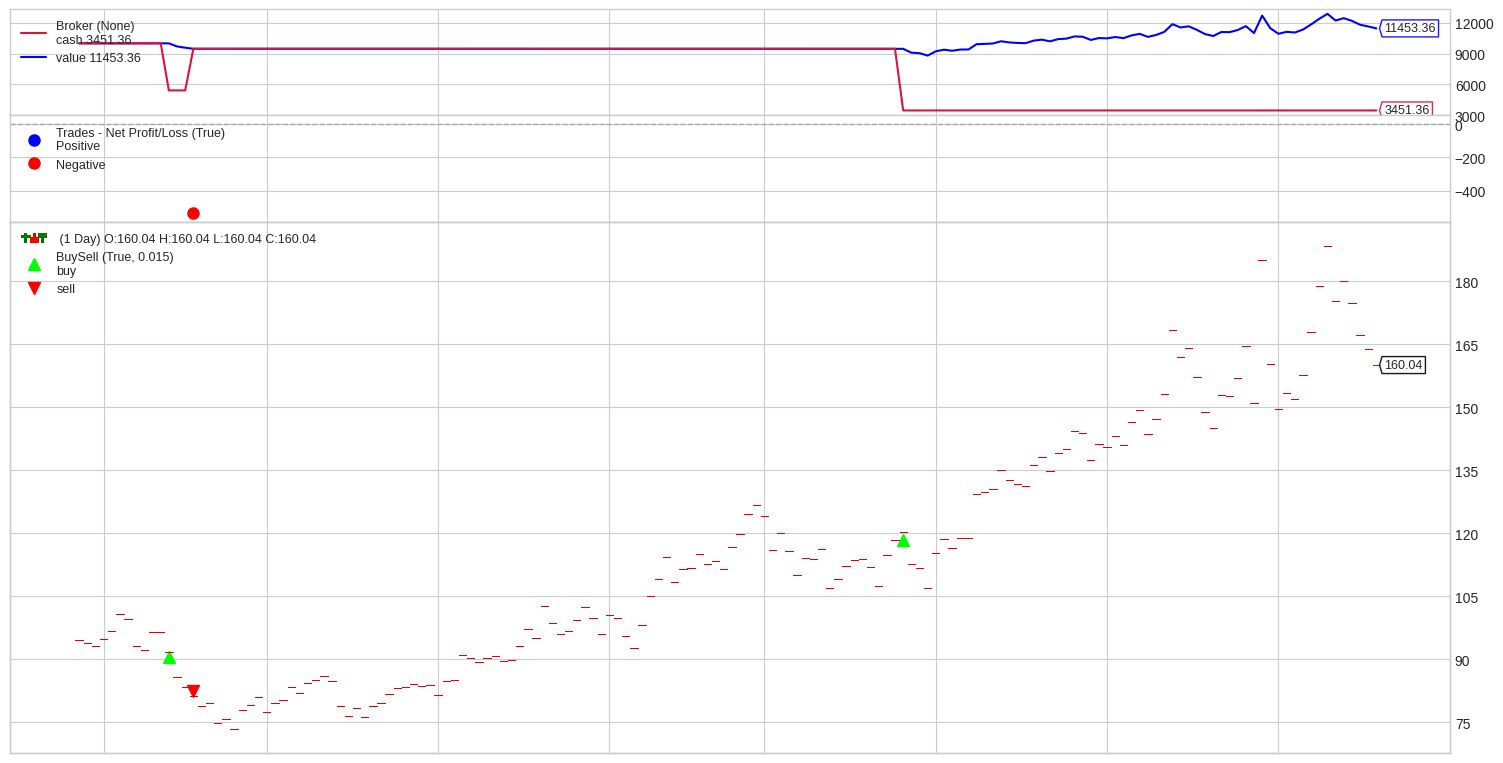

[[<Figure size 1600x800 with 4 Axes>]]

In [36]:
# =========================================================
# BƯỚC 5: BACKTESTING BẰNG BACKTRADER (CHỈ DÙNG DỮ LIỆU THẬT)
# =========================================================
import backtrader as bt
import pandas as pd
import matplotlib.pyplot as plt

print("🔍 Đang tìm kiếm dữ liệu thật của bạn trong bộ nhớ RAM...")

# BẮT BUỘC PHẢI TÌM THẤY DỮ LIỆU THẬT
if 'pdf_plot' in globals():
    print("✅ Đã tìm thấy dữ liệu thật (pdf_plot). Đang nạp vào Backtrader...")
    bt_df = pdf_plot.copy()
elif 'df_signals' in globals():
    print("✅ Đã tìm thấy dữ liệu thật (df_signals). Đang nạp vào Backtrader...")
    bt_df = df_signals.toPandas()
else:
    # Nếu RAM trống, báo lỗi đỏ và yêu cầu chạy lại từ đầu
    raise ValueError("❌ LỖI: BỘ NHỚ RAM ĐANG TRỐNG! Hệ thống không tìm thấy dữ liệu thật của bạn. \\n👉 CÁCH SỬA: Hãy lên menu trên cùng, bấm chọn 'Kernel' -> 'Restart & Run All' để máy tính tính toán lại dữ liệu từ đầu!")

# ---------------------------------------------------------
# CÁC BƯỚC CHẠY BACKTEST TRÊN DỮ LIỆU THẬT
# ---------------------------------------------------------
# Chuẩn hóa DataFrame cho Backtrader
bt_df['trade_date'] = pd.to_datetime(bt_df['trade_date'])
bt_df.set_index('trade_date', inplace=True)

# Gán giá trị cột để Backtrader đọc được
for col in ['open', 'high', 'low', 'close']:
    bt_df[col] = bt_df['close_price']
bt_df['volume'] = 0 

# ĐỊNH NGHĨA CUSTOM DATA FEED
class SignalData(bt.feeds.PandasData):
    lines = ('signal',)
    params = (
        ('datetime', None),
        ('open', 'open'), ('high', 'high'), ('low', 'low'), ('close', 'close'),
        ('volume', 'volume'), ('openinterest', -1),
        ('signal', 'signal'), 
    )

# ĐỊNH NGHĨA CHIẾN LƯỢC GIAO DỊCH
class SentimentSMAStrategy(bt.Strategy):
    def log(self, txt, dt=None):
        dt = dt or self.datas[0].datetime.date(0)
        print(f'[{dt.isoformat()}] {txt}')

    def __init__(self):
        self.dataclose = self.datas[0].close
        self.datasignal = self.datas[0].signal
        self.order = None

    def next(self):
        if self.order:
            return

        if not self.position:
            if self.datasignal[0] == 1:
                self.log(f'>>> TÍN HIỆU MUA: Đặt lệnh tại {self.dataclose[0]:.2f}')
                self.order = self.buy()
        else:
            if self.datasignal[0] == -1:
                self.log(f'<<< TÍN HIỆU BÁN: Đặt lệnh tại {self.dataclose[0]:.2f}')
                self.order = self.sell()

    def notify_order(self, order):
        if order.status in [order.Submitted, order.Accepted]:
            return
        if order.status in [order.Completed]:
            if order.isbuy():
                self.log(f'✅ KHỚP LỆNH MUA | Giá: {order.executed.price:.2f} | Phí: {order.executed.comm:.2f}')
            elif order.issell():
                self.log(f'✅ KHỚP LỆNH BÁN | Giá: {order.executed.price:.2f} | Phí: {order.executed.comm:.2f}')
            self.bar_executed = len(self)
        elif order.status in [order.Canceled, order.Margin, order.Rejected]:
            self.log('❌ Lệnh bị hủy / Từ chối')
        self.order = None

# KHỞI CHẠY MÔ PHỎNG
cerebro = bt.Cerebro()
cerebro.addstrategy(SentimentSMAStrategy)

data = SignalData(dataname=bt_df)
cerebro.adddata(data)

# Cấu hình vốn 10.000$, phí 0.1%, mỗi lần mua 50 cổ phiếu
INITIAL_CASH = 10000.0
cerebro.broker.setcash(INITIAL_CASH)
cerebro.broker.setcommission(commission=0.001) 
cerebro.addsizer(bt.sizers.FixedSize, stake=50) 

print('='*50)
print(f'🚀 BẮT ĐẦU BACKTEST TRÊN DỮ LIỆU THẬT CỦA BẠN')
print(f'💰 Vốn khởi điểm: ${cerebro.broker.getvalue():.2f}')
print('='*50)

cerebro.run()

final_value = cerebro.broker.getvalue()
pnl = final_value - INITIAL_CASH
pnl_percent = (pnl / INITIAL_CASH) * 100

print('='*50)
print(f'🏁 KẾT THÚC BACKTEST')
print(f'💰 Vốn cuối cùng: ${final_value:.2f}')
if pnl >= 0:
    print(f'📈 LỢI NHUẬN RÒNG (PnL): +${pnl:.2f} (+{pnl_percent:.2f}%)')
else:
    print(f'📉 THUA LỖ RÒNG (PnL): -${abs(pnl):.2f} ({pnl_percent:.2f}%)')
print('='*50)

# VẼ BIỂU ĐỒ
plt.rcParams['figure.figsize'] = [16, 8]
plt.rcParams['figure.dpi'] = 100
cerebro.plot(iplot=False, style='candlestick', barup='green', bardown='red')